In [1]:
import os
os.chdir('../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from loguru import logger
import kmedoids 
import chemiscope
import persim

from src.datasets import QM9Dataset
from src.features import get_features_xyz, get_raw_xyz_features
from src.non_euclidean import Grassmann, Riemann, PersistentHomology, Wasserstein
from src.helper_functions import align_frames_to_dist_matrix, get_distances

In [3]:
qm9 = QM9Dataset()
qm9.load()
frames = qm9.export_subset_xyz()

2026-03-06 13:07:47.247 | INFO     | src.datasets:load:109 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-06 13:07:47.907 | DEBUG    | src.datasets:export_subset_xyz:543 - Skipping qm9_686: Embedding failed.
2026-03-06 13:07:49.830 | SUCCESS  | src.datasets:export_subset_xyz:551 - Saved 1999 molecules to data/QM9/qm9_subset.xyz (failed: 1, requested: 2000).


In [4]:
distance_matrices = get_distances(frames)

2026-03-06 13:07:49.839 | INFO     | src.helper_functions:get_distances:121 - Loading grassmann_qr distance matrix...
2026-03-06 13:07:49.854 | INFO     | src.helper_functions:get_distances:121 - Loading grassmann_svd distance matrix...
2026-03-06 13:07:49.872 | INFO     | src.helper_functions:get_distances:121 - Loading euclidean_riemann distance matrix...
2026-03-06 13:07:49.890 | INFO     | src.helper_functions:get_distances:121 - Loading affine_riemann distance matrix...
2026-03-06 13:07:49.906 | INFO     | src.helper_functions:get_distances:121 - Loading wasserstein distance matrix...
2026-03-06 13:07:49.921 | INFO     | src.helper_functions:get_distances:121 - Loading ph_bottleneck distance matrix...
2026-03-06 13:07:49.936 | INFO     | src.helper_functions:get_distances:121 - Loading ph_sliced_wasserstein distance matrix...
2026-03-06 13:07:49.951 | SUCCESS  | src.helper_functions:get_distances:128 - ✓ All distance matrices are ready!


In [5]:
distance_matrices['wasserstein'].shape

(1999, 1999)

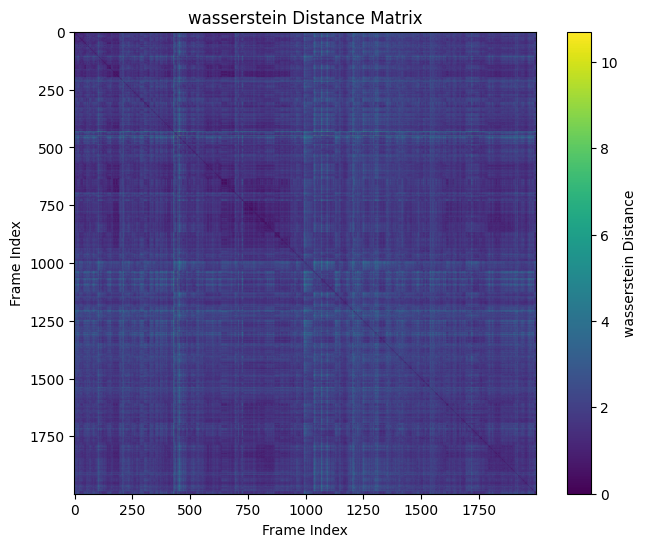

In [6]:
def show_distance_matrix(distance_matrix, method):
    plt.figure(figsize=(8, 6))
    plt.imshow(distance_matrix, cmap='viridis')
    plt.colorbar(label=f'{method} Distance')
    plt.title(f"{method} Distance Matrix")
    plt.xlabel("Frame Index")
    plt.ylabel("Frame Index")
    plt.show()

show_distance_matrix(distance_matrices['wasserstein'], 'wasserstein')

In [ ]:
def build_cluster_analysis_df(frames, cluster_labels):
    """Build a per-frame dataframe used for cluster composition/property analysis."""
    return pl.DataFrame({
        "cluster": cluster_labels,
        "true_mol_id": [f.info.get('mol_id', '') for f in frames],
        "smiles": [f.info.get('smiles', '') for f in frames],
        "structure_type": [f.info.get('structure_type', '') for f in frames],
        "functional_groups": [f.info.get('functional_groups', '') for f in frames],
        "heavy_atom_count": [f.info.get('heavy_atom_count', None) for f in frames],
        "element_ratio_C": [f.info.get('element_ratio_C', None) for f in frames],
        "element_ratio_N": [f.info.get('element_ratio_N', None) for f in frames],
        "element_ratio_O": [f.info.get('element_ratio_O', None) for f in frames],
        "element_ratio_F": [f.info.get('element_ratio_F', None) for f in frames],
        "mu": [f.info.get('mu', None) for f in frames],
        "gap": [f.info.get('gap', None) for f in frames],
        "cv": [f.info.get('cv', None) for f in frames],
        "u0": [f.info.get('u0', None) for f in frames],
        "homo": [f.info.get('homo', None) for f in frames],
        "lumo": [f.info.get('lumo', None) for f in frames],
    })


def summarize_cluster_profiles(analysis_df, label_col='cluster'):
    """Per-cluster means/variances for size, elemental makeup, and QM9 quantum properties."""
    cols = [
        "heavy_atom_count",
        "element_ratio_C", "element_ratio_N", "element_ratio_O", "element_ratio_F",
        "mu", "gap", "cv", "u0", "homo", "lumo",
    ]
    valid_cols = [c for c in cols if c in analysis_df.columns]

    exprs = [pl.len().alias('n_samples')]
    for c in valid_cols:
        exprs.append(pl.col(c).cast(pl.Float64, strict=False).mean().alias(f"avg_{c}"))
        exprs.append(pl.col(c).cast(pl.Float64, strict=False).var().alias(f"var_{c}"))

    return analysis_df.group_by(label_col).agg(exprs).sort(label_col)


from sklearn.cluster import SpectralClustering
from tqdm import tqdm

def evaluate_k_for_distance_matrices(
    distance_sets,
    k_range=range(2, 50),
    random_state=42,
    max_silhouette_samples=10_000,
    frames=None,
    return_cluster_profiles=False,
    algorithm='k_medoids',
):
    """
    Evaluate candidate k values for one or more precomputed distance matrices.

    Parameters
    ----------
    distance_sets : dict[str, np.ndarray]
        Mapping from name -> square pairwise distance matrix.
    k_range : iterable[int]
        Cluster counts to evaluate.
    random_state : int
        Seed for reproducibility.
    max_silhouette_samples : int
        Max number of samples used for silhouette score.
    frames : list[ase.Atoms] | None
        Optional exported frames with metadata from export_subset_xyz.
    return_cluster_profiles : bool
        If True, return per-cluster size/composition/QM summaries at best k.
    algorithm : str
        The clustering algorithm to use. Must be 'k_medoids' or 'spectral'.
    """
    
    if algorithm not in ['k_medoids', 'spectral']:
        raise ValueError("algorithm must be either 'k_medoids' or 'spectral'")
        
    results = {name: {'inertia': [], 'silhouette': []} for name in distance_sets}

    for name, dist_matrix in list(distance_sets.items()):
        dist_matrix = np.asarray(dist_matrix)
        if dist_matrix.ndim != 2 or dist_matrix.shape[0] != dist_matrix.shape[1]:
            raise ValueError(f"Distance matrix '{name}' must be square. Got {dist_matrix.shape}.")

        if np.isnan(dist_matrix).any():
            print(f"Skipping '{name}': contains NaNs.")
            results.pop(name, None)
            continue

        n = dist_matrix.shape[0]
        valid_k = [k for k in k_range if 2 <= k < n]
        if not valid_k:
            raise ValueError(
                f"No valid k values for '{name}'. Need 2 <= k < n_samples (n={n})."
            )
            
        # If using spectral clustering, convert distance to an affinity matrix
        if algorithm == 'spectral':
            # Using an RBF kernel-like conversion: exp(-d^2 / (2 * variance))
            variance = np.var(dist_matrix)
            if variance == 0: variance = 1e-10
            affinity_matrix = np.exp(- (dist_matrix ** 2) / (2.0 * variance))

        progress_desc = f"Processing {name} (n={n}, algo={algorithm})"
        for k in tqdm(valid_k, desc=progress_desc):
            if algorithm == 'k_medoids':
                model = kmedoids.KMedoids(n_clusters=k, random_state=random_state)
                labels = model.fit_predict(dist_matrix)
                
                if hasattr(model, 'inertia_') and model.inertia_ is not None:
                    cost = float(model.inertia_)
                elif hasattr(model, 'error_'):
                    cost = float(model.error_)
                elif hasattr(model, 'medoid_indices_'):
                    medoids = model.medoid_indices_
                    cost = np.sum(np.min(dist_matrix[:, medoids], axis=1))
                else:
                    cost = np.nan
                    
            elif algorithm == 'spectral':
                model = SpectralClustering(
                    n_clusters=k, 
                    affinity='precomputed', 
                    random_state=random_state,
                    assign_labels='kmeans'
                )
                labels = model.fit_predict(affinity_matrix)
                cost = np.nan # Spectral clustering doesn't have a direct inertia metric

            results[name]['inertia'].append(cost)

            if n > max_silhouette_samples:
                sil = silhouette_score(
                    dist_matrix,
                    labels,
                    metric='precomputed',
                    sample_size=max_silhouette_samples,
                    random_state=random_state,
                )
            else:
                sil = silhouette_score(dist_matrix, labels, metric='precomputed')
            results[name]['silhouette'].append(float(sil))

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    for name, metrics in results.items():
        n = np.asarray(distance_sets[name]).shape[0]
        valid_k = [k for k in k_range if 2 <= k < n]
        ax1.plot(valid_k, metrics['inertia'], marker='o', label=name)

    algo_title_prefix = "K-Medoids" if algorithm == 'k_medoids' else "Spectral Clustering"
    ax1.set_title(f'{algo_title_prefix} Objective (Inertia)')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia (Elbow method)' if algorithm == 'k_medoids' else 'Inertia (N/A for Spectral)')
    ax1.legend()
    ax1.grid(True)

    for name, metrics in results.items():
        n = np.asarray(distance_sets[name]).shape[0]
        valid_k = [k for k in k_range if 2 <= k < n]
        ax2.plot(valid_k, metrics['silhouette'], marker='s', linestyle='--', label=name)

    ax2.set_title(f'{algo_title_prefix} Silhouette Score (Precomputed Distances)')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Silhouette Score (Higher is better)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # --- Summarize ---
    best_k = {}
    for name, metrics in results.items():
        if metrics['silhouette']:
            idx = int(np.argmax(metrics['silhouette']))
            ks = [k for k in k_range if 2 <= k < np.asarray(distance_sets[name]).shape[0]]
            best_k[name] = ks[idx]

    summary = pl.DataFrame(
        {
            'name': list(best_k.keys()),
            'best_k_by_silhouette': list(best_k.values()),
            'best_silhouette': [max(results[name]['silhouette']) for name in best_k],
        }
    )

    from IPython.display import display
    display(summary)

    # --- Cluster Profiles ---
    cluster_profiles = {}
    if return_cluster_profiles and frames is not None:
        for name, k in best_k.items():
            dist_matrix = np.asarray(distance_sets[name])
            active_frames = align_frames_to_dist_matrix(frames, dist_matrix=dist_matrix)
            
            # Refit with chosen algorithm
            if algorithm == 'k_medoids':
                labels = kmedoids.KMedoids(n_clusters=k, random_state=random_state).fit_predict(dist_matrix)
            elif algorithm == 'spectral':
                variance = np.var(dist_matrix)
                if variance == 0: variance = 1e-10
                affinity_matrix = np.exp(- (dist_matrix ** 2) / (2.0 * variance))
                labels = SpectralClustering(
                    n_clusters=k, 
                    affinity='precomputed', 
                    random_state=random_state,
                    assign_labels='kmeans'
                ).fit_predict(affinity_matrix)
                
            analysis_df = build_cluster_analysis_df(active_frames, labels)
            cluster_profiles[name] = summarize_cluster_profiles(analysis_df)

        if cluster_profiles:
            print()
            print("Per-cluster profile at best k (size/composition/QM properties):")
            for metric_name, profile_df in cluster_profiles.items():
                print()
                print(f"{metric_name}")
                display(profile_df)

    return results, summary, cluster_profiles



Processing grassmann_qr (n=1999, algo=k_medoids):   0%|          | 0/48 [00:00<?, ?it/s]

Processing grassmann_qr (n=1999, algo=k_medoids): 100%|██████████| 48/48 [00:05<00:00,  8.84it/s]
Processing grassmann_svd (n=1999, algo=k_medoids): 100%|██████████| 48/48 [00:04<00:00, 10.09it/s]
Processing euclidean_riemann (n=1999, algo=k_medoids): 100%|██████████| 48/48 [00:05<00:00,  9.30it/s]
Processing affine_riemann (n=1999, algo=k_medoids): 100%|██████████| 48/48 [00:05<00:00,  9.14it/s]
Processing wasserstein (n=1999, algo=k_medoids): 100%|██████████| 48/48 [00:05<00:00,  8.51it/s]
Processing ph_bottleneck (n=1999, algo=k_medoids): 100%|██████████| 48/48 [00:04<00:00, 11.86it/s]
Processing ph_sliced_wasserstein (n=1999, algo=k_medoids): 100%|██████████| 48/48 [00:03<00:00, 12.41it/s]


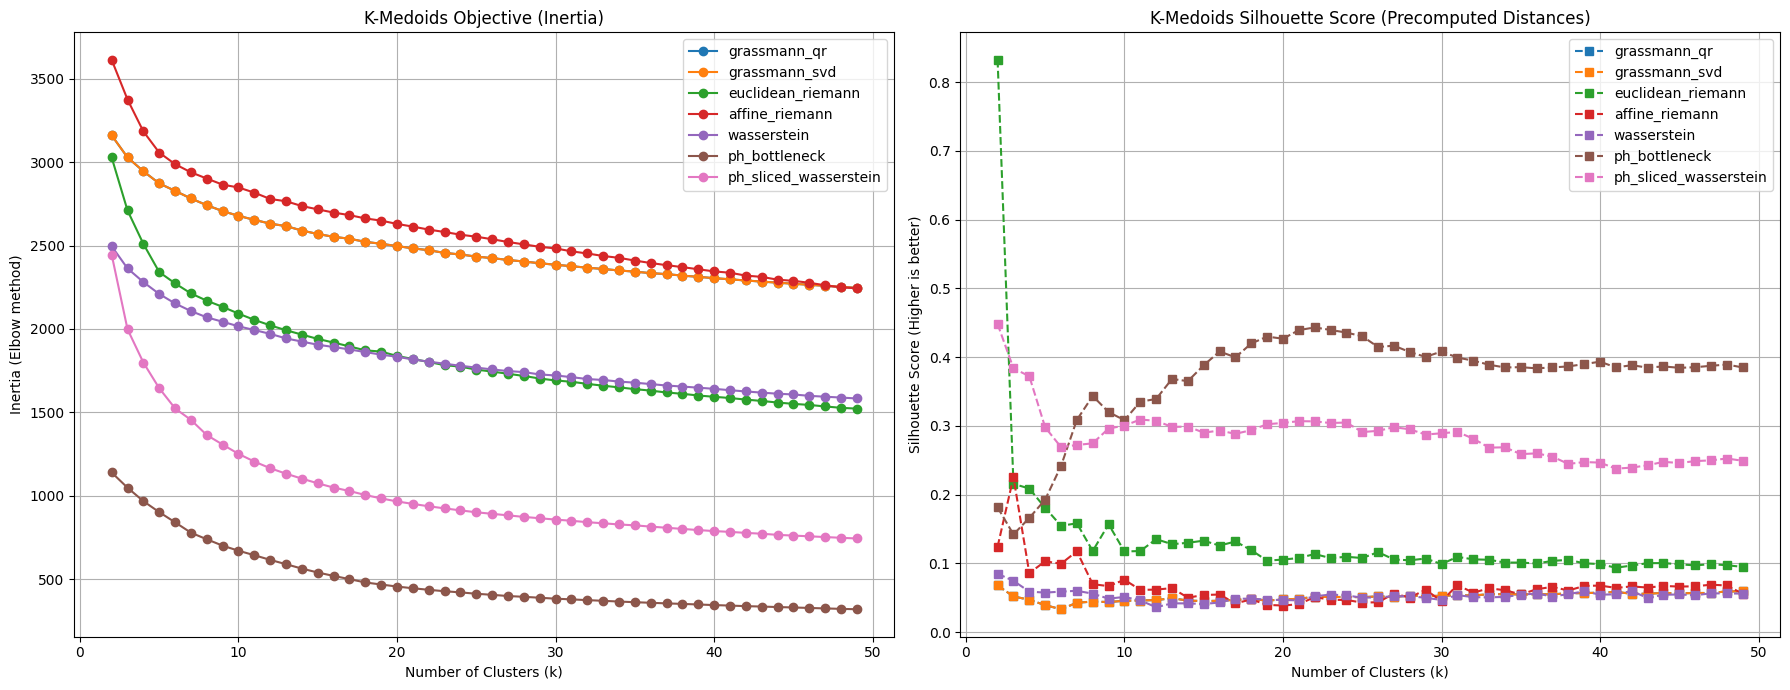

name,best_k_by_silhouette,best_silhouette
str,i64,f64
"""grassmann_qr""",2,0.067815
"""grassmann_svd""",2,0.067815
"""euclidean_riemann""",2,0.83263
"""affine_riemann""",3,0.225464
"""wasserstein""",2,0.084858
"""ph_bottleneck""",22,0.443263
"""ph_sliced_wasserstein""",2,0.448154



Per-cluster profile at best k (size/composition/QM properties):

grassmann_qr


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,877,6.662486,0.58915,0.76229,0.023379,0.076448,0.013876,0.158639,0.01295,0.002623,0.00158,2.065471,1.902385,7.878621,1.860942,26.894971,20.977964,-8375.526634,1.4717e6,-6.853065,0.479652,1.025491,1.589225
1,1122,6.431373,0.589845,0.642963,0.021082,0.15647,0.023426,0.199675,0.015782,0.000891,0.000445,2.703303,2.121716,6.924233,1.552082,22.694284,14.365734,-8537.403018,1.6879e6,-6.769749,0.592542,0.154431,1.575722



grassmann_svd


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,877,6.662486,0.58915,0.76229,0.023379,0.076448,0.013876,0.158639,0.01295,0.002623,0.00158,2.065471,1.902385,7.878621,1.860942,26.894971,20.977964,-8375.526634,1.4717e6,-6.853065,0.479652,1.025491,1.589225
1,1122,6.431373,0.589845,0.642963,0.021082,0.15647,0.023426,0.199675,0.015782,0.000891,0.000445,2.703303,2.121716,6.924233,1.552082,22.694284,14.365734,-8537.403018,1.6879e6,-6.769749,0.592542,0.154431,1.575722


...

cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1046,6.447419,0.691491,0.694985,0.028446,0.1205,0.022087,0.18136,0.016166,0.003155,0.001799,2.240846,2.119303,7.450654,2.023429,23.935986,22.373686,-8363.838211,1.8173e6,-6.788484,0.638474,0.662126,1.836906
1,953,6.626443,0.48846,0.695675,0.022474,0.12231,0.019418,0.182014,0.013625,0.0,0.0,2.623924,2.056032,7.224717,1.763123,25.1971,19.950741,-8578.938379,1.3362e6,-6.825858,0.441104,0.398785,1.657441



ph_bottleneck


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,54,6.925926,0.069881,0.915344,0.00656,0.015873,0.002054,0.068783,0.005191,0.0,0.0,0.74872,0.487925,9.329323,0.555079,32.936963,3.588029,-7943.060276,417672.06029,-7.203811,0.415867,2.125209,0.106844
1,162,6.481481,0.338164,0.687272,0.016484,0.122781,0.013977,0.189947,0.013183,0.0,0.0,2.738046,1.574472,7.440114,1.377607,25.039586,6.662751,-8460.042363,1.2590e6,-6.945622,0.235089,0.494525,1.339498
2,105,6.161905,0.579304,0.643175,0.023344,0.13712,0.018878,0.219705,0.018427,0.0,0.0,2.796345,2.297288,7.088229,1.399335,22.765905,7.128459,-8268.435812,2.1776e6,-7.155713,0.274253,-0.067458,1.434365
3,54,5.814815,1.021663,0.59515,0.022816,0.145106,0.014938,0.250485,0.021113,0.009259,0.00463,3.030069,3.25323,6.723984,2.657524,20.323778,9.69117,-8077.222937,3.1700e6,-7.372068,0.434808,-0.648236,2.589421
4,123,6.96748,0.048114,0.72048,0.009366,0.086334,0.015022,0.193186,0.012678,0.0,0.0,2.396865,1.324941,7.028745,1.151594,24.763455,2.049178,-8984.004589,482964.260093,-6.47173,0.42115,0.557037,0.926445
5,43,5.860465,0.361019,0.367553,0.024473,0.408749,0.045531,0.223699,0.018991,0.0,0.0,2.909919,1.99775,6.531998,0.378363,15.279535,5.570851,-8526.518305,1.1358e6,-7.392194,0.965404,-0.860323,0.887003
6,74,6.594595,0.244354,0.804698,0.011338,0.106178,0.00707,0.089125,0.005561,0.0,0.0,1.954682,2.010975,8.427954,1.203131,28.780149,5.389478,-7947.526572,904151.580066,-6.859439,0.521737,1.568553,0.572359
7,144,6.583333,0.258741,0.730159,0.017705,0.09995,0.008097,0.169891,0.010734,0.0,0.0,2.511267,3.088291,7.99,1.258426,27.136965,5.193185,-8425.577393,1.2872e6,-6.843985,0.244328,1.145713,0.923798
8,70,5.985714,0.680952,0.632993,0.020207,0.152993,0.02072,0.214014,0.016302,0.0,0.0,3.076964,2.173834,6.780455,2.157443,21.811371,5.528683,-8010.681616,1.7970e6,-7.2965,0.311547,-0.516083,1.745215



ph_sliced_wasserstein


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,927,6.8274,0.18184,0.775451,0.015844,0.06445,0.009241,0.160099,0.011878,0.0,0.0,2.009742,1.694213,7.866169,1.550874,27.842793,8.679485,-8550.170652,938460.056256,-6.755422,0.297174,1.110662,1.169973
1,1072,6.277985,0.82648,0.626017,0.023669,0.170578,0.025594,0.200326,0.016864,0.003078,0.001755,2.781244,2.22265,6.890486,1.782526,21.678739,15.16444,-8393.931762,2.1597e6,-6.850299,0.754598,0.040152,1.75438


In [22]:
results, summary, best_k_profiles = evaluate_k_for_distance_matrices(
    distance_matrices,
    frames=frames,
    return_cluster_profiles=True,
    algorithm='k_medoids'
)


# best number of clusters
- grassmann 2
- affine riemann 5
- euclidean riemann 5
- others 2
- ph-bottleneck 22

In [9]:
def make_clustering(frames, rotational_invariant=False, dist_matrix=None, metric_name="euclidean", num_clusters = 2):
    """
    Unified clustering function handling both feature matrices and precomputed distance matrices.
    """
    active_frames = align_frames_to_dist_matrix(frames, dist_matrix=dist_matrix)
    true_labels = [f.info.get('mol_id', '') for f in active_frames]
    smiles_list = [f.info.get('smiles', '') for f in active_frames]
    base_or_pertubated = [f.info.get('frame_type', 'base') for f in active_frames]
    structure = [f.info.get('structure_type', '') for f in active_frames]
    functional_groups = [f.info.get('functional_groups', '') for f in active_frames]
    heavy_atoms = [f.info.get('heavy_atom_count', '') for f in active_frames]
    polar = [f.info.get('mu', '') for f in active_frames]
    internal_energy = [f.info.get('u0', '') for f in active_frames]
    humo_lumo = [f.info.get('gap', '') for f in active_frames]
    num_atoms = [f.info.get('num_atoms', '') for f in active_frames]
    total_mass = [f.info.get('total_mass', '') for f in active_frames]
    charge = [f.info.get('mean_partial_charge', '') for f in active_frames]
    cv = [f.info.get('cv', '') for f in active_frames]

    n_clusters = num_clusters

    if dist_matrix is not None:
        print(f"Using precomputed {metric_name} distance matrix (Shape: {dist_matrix.shape})")

        clustering = kmedoids.KMedoids(n_clusters)
        cluster_labels = clustering.fit_predict(dist_matrix)

        tsne = TSNE(
            n_components=2,
            metric='precomputed',
            init='random',
            random_state=42,
            perplexity=30
        )
        X_tsne = tsne.fit_transform(dist_matrix)

        suffix = metric_name

    else:
        print("Using feature-based representation...")
        if rotational_invariant:
            X = get_features_xyz(active_frames)
            suffix = "invariant"
        else:
            X = get_raw_xyz_features(active_frames)
            suffix = "raw"

        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)

        tsne = TSNE(
            n_components=2,
            random_state=42,
            perplexity=30,
            init='pca'
        )
        X_tsne = tsne.fit_transform(X)

    ari_score = adjusted_rand_score(true_labels, cluster_labels)
    print()
    print(f"Clustering Performance (Adjusted Rand Index) [{suffix}]: {ari_score:.4f}")

    analysis_df = build_cluster_analysis_df(active_frames, cluster_labels)

    summary_table = (
        analysis_df.group_by("cluster")
        .agg([
            pl.col("true_mol_id").n_unique().alias("unique_mols"),
            pl.col("true_mol_id").unique().alias("mol_ids_in_cluster"),
            pl.col("smiles").first().alias("representative_smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )

    profile_table = summarize_cluster_profiles(analysis_df)

    pl.Config.set_fmt_str_lengths(1000)
    pl.Config.set_tbl_rows(100)
    pl.Config.set_fmt_table_cell_list_len(50)
    print()
    print("Cluster Composition Summary:")
    display(summary_table)
    print()
    print("Cluster Size/Composition/QM Property Summary:")
    display(profile_table)

    structures = active_frames

    properties = {
        "t-SNE 1": X_tsne[:, 0],
        "t-SNE 2": X_tsne[:, 1],
        "Cluster": cluster_labels,
        "True Mol ID": true_labels,
        "SMILES": smiles_list,
        "Frame Type": base_or_pertubated,
        "Structure": structure,
        "Functional Groups": functional_groups,
        # "Heavy Atom Count": heavy_atoms,
        # "Dipole (mu)": polar,
        # "HOMO-LUMO Gap": humo_lumo,
        # "Heat Capacity (Cv)": cv,
        # "Internal Energy (U0)": internal_energy,
        # "Total Mass": total_mass,
    }

    output_path = f"report/qm9/figures/grassmann/chemiscope_clustering_{suffix}.json.gz"

    chemiscope.write_input(
        output_path,
        properties=properties,
        structures=structures,
    )

    print()
    print(f"Chemiscope file successfully saved to: {output_path}")

    return summary_table, profile_table, output_path



In [10]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['grassmann_qr'], num_clusters=2)


Using precomputed euclidean distance matrix (Shape: (1999, 1999))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1122,"[""qm9_2"", ""qm9_4"", ""qm9_10"", ""qm9_12"", ""qm9_13"", ""qm9_14"", ""qm9_15"", ""qm9_17"", ""qm9_18"", ""qm9_19"", ""qm9_21"", ""qm9_23"", ""qm9_29"", ""qm9_30"", ""qm9_34"", ""qm9_41"", ""qm9_42"", ""qm9_43"", ""qm9_44"", ""qm9_45"", ""qm9_46"", ""qm9_47"", ""qm9_48"", ""qm9_49"", ""qm9_50"", ""qm9_51"", ""qm9_55"", ""qm9_57"", ""qm9_58"", ""qm9_61"", ""qm9_62"", ""qm9_63"", ""qm9_64"", ""qm9_65"", ""qm9_66"", ""qm9_67"", ""qm9_68"", ""qm9_69"", ""qm9_70"", ""qm9_71"", ""qm9_72"", ""qm9_73"", ""qm9_74"", ""qm9_75"", ""qm9_76"", ""qm9_78"", ""qm9_80"", ""qm9_82"", ""qm9_83"", … ""qm9_2232""]","""[H]O[H]""",1122
1,877,"[""qm9_0"", ""qm9_1"", ""qm9_3"", ""qm9_5"", ""qm9_6"", ""qm9_7"", ""qm9_8"", ""qm9_9"", ""qm9_11"", ""qm9_16"", ""qm9_20"", ""qm9_24"", ""qm9_25"", ""qm9_26"", ""qm9_27"", ""qm9_31"", ""qm9_32"", ""qm9_33"", ""qm9_35"", ""qm9_36"", ""qm9_37"", ""qm9_38"", ""qm9_39"", ""qm9_40"", ""qm9_52"", ""qm9_53"", ""qm9_54"", ""qm9_56"", ""qm9_59"", ""qm9_77"", ""qm9_79"", ""qm9_81"", ""qm9_96"", ""qm9_98"", ""qm9_109"", ""qm9_118"", ""qm9_129"", ""qm9_134"", ""qm9_138"", ""qm9_155"", ""qm9_162"", ""qm9_168"", ""qm9_169"", ""qm9_170"", ""qm9_171"", ""qm9_172"", ""qm9_173"", ""qm9_176"", ""qm9_180"", … ""qm9_2235""]","""[H]C([H])([H])[H]""",877



Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1122,6.431373,0.589845,0.642963,0.021082,0.15647,0.023426,0.199675,0.015782,0.000891,0.000445,2.703303,2.121716,6.924233,1.552082,22.694284,14.365734,-8537.403018,1.6879e6,-6.769749,0.592542,0.154431,1.575722
1,877,6.662486,0.58915,0.76229,0.023379,0.076448,0.013876,0.158639,0.01295,0.002623,0.00158,2.065471,1.902385,7.878621,1.860942,26.894971,20.977964,-8375.526634,1.4717e6,-6.853065,0.479652,1.025491,1.589225



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [11]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

2 clusters:
- cluster 0: split in 2:
    - top left: small molecules. (avg is 92. almost all of these are smaller.) all of htem have nitrogen and oxygen.
    - bottom right: mostly acyclic. also some cyclic. no aromatic. many alcohol.
- cluste 1: aromatic molecules. also acyclic. 

# Riemann

In [12]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['euclidean_riemann'], num_clusters=5)
chemiscope.show_input(output_path)


Using precomputed euclidean distance matrix (Shape: (1999, 1999))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,85,"[""qm9_1"", ""qm9_2"", ""qm9_3"", ""qm9_4"", ""qm9_5"", ""qm9_24"", ""qm9_25"", ""qm9_26"", ""qm9_27"", ""qm9_49"", ""qm9_50"", ""qm9_51"", ""qm9_52"", ""qm9_110"", ""qm9_162"", ""qm9_163"", ""qm9_164"", ""qm9_165"", ""qm9_167"", ""qm9_168"", ""qm9_169"", ""qm9_170"", ""qm9_171"", ""qm9_172"", ""qm9_173"", ""qm9_181"", ""qm9_182"", ""qm9_183"", ""qm9_208"", ""qm9_209"", ""qm9_210"", ""qm9_211"", ""qm9_311"", ""qm9_312"", ""qm9_313"", ""qm9_474"", ""qm9_476"", ""qm9_711"", ""qm9_712"", ""qm9_713"", ""qm9_714"", ""qm9_715"", ""qm9_760"", ""qm9_761"", ""qm9_762"", ""qm9_763"", ""qm9_764"", ""qm9_765"", ""qm9_884"", … ""qm9_2062""]","""[H]N([H])[H]""",85
1,309,"[""qm9_31"", ""qm9_32"", ""qm9_33"", ""qm9_35"", ""qm9_36"", ""qm9_37"", ""qm9_55"", ""qm9_56"", ""qm9_57"", ""qm9_59"", ""qm9_67"", ""qm9_72"", ""qm9_75"", ""qm9_76"", ""qm9_103"", ""qm9_106"", ""qm9_113"", ""qm9_137"", ""qm9_140"", ""qm9_174"", ""qm9_184"", ""qm9_185"", ""qm9_186"", ""qm9_187"", ""qm9_188"", ""qm9_189"", ""qm9_191"", ""qm9_192"", ""qm9_193"", ""qm9_194"", ""qm9_195"", ""qm9_196"", ""qm9_197"", ""qm9_198"", ""qm9_199"", ""qm9_200"", ""qm9_201"", ""qm9_202"", ""qm9_203"", ""qm9_204"", ""qm9_205"", ""qm9_226"", ""qm9_241"", ""qm9_242"", ""qm9_273"", ""qm9_314"", ""qm9_320"", ""qm9_322"", ""qm9_328"", … ""qm9_2091""]","""[H]N([H])C([H])([H])C#N""",309
2,778,"[""qm9_7"", ""qm9_11"", ""qm9_13"", ""qm9_14"", ""qm9_18"", ""qm9_19"", ""qm9_23"", ""qm9_39"", ""qm9_41"", ""qm9_44"", ""qm9_45"", ""qm9_48"", ""qm9_58"", ""qm9_63"", ""qm9_64"", ""qm9_66"", ""qm9_68"", ""qm9_70"", ""qm9_71"", ""qm9_73"", ""qm9_74"", ""qm9_78"", ""qm9_85"", ""qm9_87"", ""qm9_88"", ""qm9_89"", ""qm9_90"", ""qm9_100"", ""qm9_107"", ""qm9_108"", ""qm9_109"", ""qm9_112"", ""qm9_114"", ""qm9_116"", ""qm9_120"", ""qm9_121"", ""qm9_122"", ""qm9_123"", ""qm9_125"", ""qm9_126"", ""qm9_127"", ""qm9_128"", ""qm9_134"", ""qm9_136"", ""qm9_143"", ""qm9_147"", ""qm9_150"", ""qm9_151"", ""qm9_153"", … ""qm9_2232""]","""[H]OC([H])([H])[H]""",778
3,162,"[""qm9_0"", ""qm9_6"", ""qm9_9"", ""qm9_12"", ""qm9_15"", ""qm9_16"", ""qm9_20"", ""qm9_30"", ""qm9_38"", ""qm9_42"", ""qm9_46"", ""qm9_53"", ""qm9_61"", ""qm9_79"", ""qm9_82"", ""qm9_91"", ""qm9_96"", ""qm9_101"", ""qm9_111"", ""qm9_115"", ""qm9_117"", ""qm9_118"", ""qm9_129"", ""qm9_135"", ""qm9_138"", ""qm9_145"", ""qm9_152"", ""qm9_155"", ""qm9_158"", ""qm9_213"", ""qm9_222"", ""qm9_227"", ""qm9_243"", ""qm9_244"", ""qm9_266"", ""qm9_281"", ""qm9_284"", ""qm9_291"", ""qm9_301"", ""qm9_306"", ""qm9_361"", ""qm9_362"", ""qm9_388"", ""qm9_389"", ""qm9_404"", ""qm9_422"", ""qm9_449"", ""qm9_452"", ""qm9_456"", … ""qm9_2233""]","""[H]C([H])([H])[H]""",162
4,665,"[""qm9_8"", ""qm9_10"", ""qm9_17"", ""qm9_21"", ""qm9_29"", ""qm9_34"", ""qm9_40"", ""qm9_43"", ""qm9_47"", ""qm9_54"", ""qm9_62"", ""qm9_65"", ""qm9_69"", ""qm9_77"", ""qm9_80"", ""qm9_81"", ""qm9_83"", ""qm9_84"", ""qm9_86"", ""qm9_92"", ""qm9_93"", ""qm9_94"", ""qm9_97"", ""qm9_98"", ""qm9_99"", ""qm9_104"", ""qm9_119"", ""qm9_124"", ""qm9_130"", ""qm9_131"", ""qm9_132"", ""qm9_139"", ""qm9_141"", ""qm9_146"", ""qm9_148"", ""qm9_149"", ""qm9_154"", ""qm9_160"", ""qm9_177"", ""qm9_215"", ""qm9_216"", ""qm9_217"", ""qm9_218"", ""qm9_220"", ""qm9_223"", ""qm9_224"", ""qm9_229"", ""qm9_230"", ""qm9_231"", … ""qm9_2235""]","""[H]C#CC([H])([H])[H]""",665



Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,85,5.894118,1.976751,0.550168,0.045324,0.282773,0.047538,0.167059,0.028211,0.0,0.0,2.91254,3.21805,6.071628,1.42825,16.315859,18.127734,-7831.59855,3.5149e6,-7.148079,1.091457,-1.076418,1.607151
1,309,6.537217,0.450721,0.576661,0.01907,0.2544,0.024698,0.16894,0.014126,0.0,0.0,2.734912,2.218724,6.313376,0.594846,21.850466,10.52885,-8719.262209,1.0547e6,-6.194967,0.902845,0.118303,1.325443
2,778,6.602828,0.471395,0.621426,0.009844,0.12059,0.013742,0.253743,0.011391,0.004242,0.002414,2.732659,2.041227,7.169459,1.562145,24.594557,14.321377,-9050.727201,1.2019e6,-6.921755,0.341942,0.247655,1.609088
3,162,6.197531,1.178131,0.966093,0.00886,0.031849,0.008306,0.002058,0.000686,0.0,0.0,0.85379,2.042668,9.052019,1.621091,25.822679,32.362155,-6686.370446,1.3445e6,-7.332494,0.77875,1.719474,0.615258
4,665,6.61203,0.424554,0.789481,0.006329,0.061625,0.009937,0.148894,0.006225,0.0,0.0,2.236915,1.249448,7.770455,1.441858,26.456235,17.120627,-8180.011083,807691.879345,-6.783422,0.219913,0.986971,1.412271



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

- riemann makes clear cluster with aromatic structures when using 2 clusters
- 5 clusters:
    - cluster 0: cyclic (or acyclic) no functional groups. fairly complex molecules
    - cluster 1: aromatic
    - cluster 2: a lot of functional groups. many alcohol. many containing flour.
    - cluster 3: rings, containing flour. many phenol groups. many amine. 
    - cluster 4: large diverse cluster. 

In [13]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['affine_riemann'], num_clusters=5)
chemiscope.show_input(output_path)


Using precomputed euclidean distance matrix (Shape: (1999, 1999))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,837,"[""qm9_7"", ""qm9_10"", ""qm9_13"", ""qm9_14"", ""qm9_18"", ""qm9_19"", ""qm9_23"", ""qm9_35"", ""qm9_39"", ""qm9_41"", ""qm9_43"", ""qm9_44"", ""qm9_45"", ""qm9_48"", ""qm9_58"", ""qm9_63"", ""qm9_64"", ""qm9_66"", ""qm9_67"", ""qm9_68"", ""qm9_70"", ""qm9_71"", ""qm9_73"", ""qm9_74"", ""qm9_76"", ""qm9_78"", ""qm9_85"", ""qm9_87"", ""qm9_88"", ""qm9_89"", ""qm9_90"", ""qm9_100"", ""qm9_106"", ""qm9_107"", ""qm9_108"", ""qm9_113"", ""qm9_114"", ""qm9_116"", ""qm9_120"", ""qm9_121"", ""qm9_122"", ""qm9_123"", ""qm9_125"", ""qm9_127"", ""qm9_128"", ""qm9_134"", ""qm9_136"", ""qm9_139"", ""qm9_143"", … ""qm9_2232""]","""[H]OC([H])([H])[H]""",837
1,293,"[""qm9_11"", ""qm9_16"", ""qm9_24"", ""qm9_25"", ""qm9_31"", ""qm9_32"", ""qm9_33"", ""qm9_36"", ""qm9_37"", ""qm9_50"", ""qm9_51"", ""qm9_55"", ""qm9_56"", ""qm9_57"", ""qm9_59"", ""qm9_72"", ""qm9_75"", ""qm9_109"", ""qm9_126"", ""qm9_137"", ""qm9_140"", ""qm9_169"", ""qm9_172"", ""qm9_174"", ""qm9_184"", ""qm9_185"", ""qm9_186"", ""qm9_187"", ""qm9_189"", ""qm9_191"", ""qm9_192"", ""qm9_193"", ""qm9_194"", ""qm9_195"", ""qm9_196"", ""qm9_197"", ""qm9_198"", ""qm9_199"", ""qm9_200"", ""qm9_201"", ""qm9_202"", ""qm9_203"", ""qm9_205"", ""qm9_226"", ""qm9_241"", ""qm9_242"", ""qm9_273"", ""qm9_311"", ""qm9_312"", … ""qm9_2091""]","""[H]C(=O)N([H])[H]""",293
2,157,"[""qm9_0"", ""qm9_6"", ""qm9_12"", ""qm9_15"", ""qm9_20"", ""qm9_38"", ""qm9_42"", ""qm9_46"", ""qm9_53"", ""qm9_61"", ""qm9_79"", ""qm9_82"", ""qm9_91"", ""qm9_96"", ""qm9_101"", ""qm9_111"", ""qm9_115"", ""qm9_117"", ""qm9_118"", ""qm9_129"", ""qm9_135"", ""qm9_145"", ""qm9_152"", ""qm9_155"", ""qm9_158"", ""qm9_213"", ""qm9_222"", ""qm9_227"", ""qm9_243"", ""qm9_244"", ""qm9_266"", ""qm9_281"", ""qm9_284"", ""qm9_291"", ""qm9_301"", ""qm9_306"", ""qm9_361"", ""qm9_362"", ""qm9_388"", ""qm9_389"", ""qm9_404"", ""qm9_422"", ""qm9_449"", ""qm9_452"", ""qm9_456"", ""qm9_463"", ""qm9_468"", ""qm9_495"", ""qm9_501"", … ""qm9_2233""]","""[H]C([H])([H])[H]""",157
3,75,"[""qm9_1"", ""qm9_2"", ""qm9_3"", ""qm9_4"", ""qm9_5"", ""qm9_26"", ""qm9_27"", ""qm9_49"", ""qm9_52"", ""qm9_110"", ""qm9_162"", ""qm9_163"", ""qm9_164"", ""qm9_165"", ""qm9_167"", ""qm9_168"", ""qm9_170"", ""qm9_171"", ""qm9_173"", ""qm9_181"", ""qm9_182"", ""qm9_183"", ""qm9_188"", ""qm9_204"", ""qm9_208"", ""qm9_209"", ""qm9_210"", ""qm9_211"", ""qm9_313"", ""qm9_711"", ""qm9_712"", ""qm9_713"", ""qm9_714"", ""qm9_715"", ""qm9_761"", ""qm9_762"", ""qm9_763"", ""qm9_764"", ""qm9_765"", ""qm9_770"", ""qm9_872"", ""qm9_884"", ""qm9_888"", ""qm9_894"", ""qm9_895"", ""qm9_896"", ""qm9_897"", ""qm9_898"", ""qm9_899"", … ""qm9_2062""]","""[H]N([H])[H]""",75
4,637,"[""qm9_8"", ""qm9_9"", ""qm9_17"", ""qm9_21"", ""qm9_29"", ""qm9_30"", ""qm9_34"", ""qm9_40"", ""qm9_47"", ""qm9_54"", ""qm9_62"", ""qm9_65"", ""qm9_69"", ""qm9_77"", ""qm9_80"", ""qm9_81"", ""qm9_83"", ""qm9_84"", ""qm9_86"", ""qm9_92"", ""qm9_93"", ""qm9_94"", ""qm9_97"", ""qm9_98"", ""qm9_99"", ""qm9_103"", ""qm9_104"", ""qm9_112"", ""qm9_119"", ""qm9_124"", ""qm9_130"", ""qm9_131"", ""qm9_132"", ""qm9_138"", ""qm9_141"", ""qm9_146"", ""qm9_148"", ""qm9_149"", ""qm9_154"", ""qm9_160"", ""qm9_177"", ""qm9_215"", ""qm9_216"", ""qm9_217"", ""qm9_218"", ""qm9_220"", ""qm9_223"", ""qm9_224"", ""qm9_229"", … ""qm9_2235""]","""[H]C#CC([H])([H])[H]""",637



Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,837,6.600956,0.474545,0.626728,0.009913,0.121429,0.014314,0.247901,0.011578,0.003943,0.002245,2.734912,2.00864,7.156013,1.514432,24.54254,14.147825,-9009.208929,1.2033e6,-6.90161,0.345141,0.254363,1.543597
1,293,6.467577,0.571719,0.567707,0.018788,0.255119,0.025702,0.177174,0.01462,0.0,0.0,2.714878,2.144073,6.304265,0.760577,21.31745,13.083477,-8676.27879,1.2660e6,-6.310246,1.0537,-0.006018,1.585302
2,157,6.254777,1.037237,0.973946,0.00705,0.026054,0.00705,0.0,0.0,0.0,0.0,0.789241,1.909741,9.037283,1.657679,26.15751,28.658191,-6730.831773,1.2372e6,-7.298527,0.751796,1.738704,0.595117
3,75,5.96,2.065946,0.532889,0.043376,0.298952,0.044117,0.168159,0.029821,0.0,0.0,2.853847,3.213353,6.134498,1.46005,16.673253,20.085734,-7964.699548,3.6352e6,-6.925007,1.1936,-0.790618,1.795232
4,637,6.609105,0.439728,0.79458,0.006109,0.062335,0.010187,0.143085,0.006114,0.0,0.0,2.232331,1.323366,7.791,1.462525,26.537732,17.176973,-8143.410409,847162.279854,-6.773943,0.26186,1.016967,1.405776



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

5 clusters:
- cluster 0: many flour. majority aromatic with phenol group in the middle of the cluster. on the left: acyclic flour with functional groups. on the right: aromatic phenol.
- cluster 1: many ether and ketone in top. on the right: alcohol. middle: cyclic ether.
- cluster 2: cyclic/acyclic no functional groups. almost only carbon and hydrogen.
- cluster 3: aromatic. few functional groups.
- cluster 4: acyclic. top: many functional groups and flour. bottom: cyclic ether some alcohol. left acyclic alcohol. right: like left on cluster 0.

# Earths movers distance

In [14]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['wasserstein'], num_clusters=2)
chemiscope.show_input(output_path)


Using precomputed euclidean distance matrix (Shape: (1999, 1999))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1134,"[""qm9_0"", ""qm9_1"", ""qm9_2"", ""qm9_3"", ""qm9_4"", ""qm9_5"", ""qm9_7"", ""qm9_8"", ""qm9_9"", ""qm9_10"", ""qm9_12"", ""qm9_15"", ""qm9_18"", ""qm9_19"", ""qm9_20"", ""qm9_21"", ""qm9_26"", ""qm9_27"", ""qm9_29"", ""qm9_30"", ""qm9_31"", ""qm9_33"", ""qm9_34"", ""qm9_35"", ""qm9_36"", ""qm9_37"", ""qm9_39"", ""qm9_45"", ""qm9_46"", ""qm9_47"", ""qm9_48"", ""qm9_49"", ""qm9_50"", ""qm9_51"", ""qm9_52"", ""qm9_55"", ""qm9_56"", ""qm9_57"", ""qm9_58"", ""qm9_59"", ""qm9_61"", ""qm9_62"", ""qm9_63"", ""qm9_64"", ""qm9_65"", ""qm9_66"", ""qm9_67"", ""qm9_68"", ""qm9_69"", … ""qm9_2228""]","""[H]C([H])([H])[H]""",1134
1,865,"[""qm9_6"", ""qm9_11"", ""qm9_13"", ""qm9_14"", ""qm9_16"", ""qm9_17"", ""qm9_23"", ""qm9_24"", ""qm9_25"", ""qm9_32"", ""qm9_38"", ""qm9_40"", ""qm9_41"", ""qm9_42"", ""qm9_43"", ""qm9_44"", ""qm9_53"", ""qm9_54"", ""qm9_71"", ""qm9_73"", ""qm9_74"", ""qm9_84"", ""qm9_91"", ""qm9_92"", ""qm9_93"", ""qm9_96"", ""qm9_97"", ""qm9_98"", ""qm9_99"", ""qm9_100"", ""qm9_101"", ""qm9_104"", ""qm9_107"", ""qm9_108"", ""qm9_109"", ""qm9_111"", ""qm9_114"", ""qm9_116"", ""qm9_120"", ""qm9_122"", ""qm9_123"", ""qm9_128"", ""qm9_129"", ""qm9_132"", ""qm9_134"", ""qm9_135"", ""qm9_136"", ""qm9_137"", ""qm9_139"", … ""qm9_2235""]","""[H]C([H])([H])C([H])([H])[H]""",865



Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1134,6.510582,0.682589,0.66603,0.026152,0.155274,0.025288,0.178695,0.01565,0.0,0.0,2.618228,2.023761,7.026388,1.699239,23.456131,21.906756,-8487.097743,1.6339e6,-6.732675,0.676181,0.293593,1.629184
1,865,6.56185,0.49646,0.733705,0.022274,0.076906,0.011462,0.185574,0.014016,0.003815,0.002173,2.168155,2.144527,7.757938,1.887254,25.95448,17.689249,-8439.230293,1.5531e6,-6.902824,0.355917,0.855136,1.772494



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

2 clusters:
- cluster 0: not very well seperated. no idea.

# Persistent homology

In [15]:
summary_table, profile_table, output_path = make_clustering(
    frames, 
    dist_matrix=distance_matrices['ph_bottleneck'],
    num_clusters=22
)

chemiscope.show_input(output_path)

Using precomputed euclidean distance matrix (Shape: (1999, 1999))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,54,"[""qm9_222"", ""qm9_266"", ""qm9_281"", ""qm9_533"", ""qm9_1065"", ""qm9_1067"", ""qm9_1068"", ""qm9_1069"", ""qm9_1070"", ""qm9_1076"", ""qm9_1077"", ""qm9_1078"", ""qm9_1099"", ""qm9_1100"", ""qm9_1109"", ""qm9_1113"", ""qm9_1157"", ""qm9_1158"", ""qm9_1159"", ""qm9_1160"", ""qm9_1226"", ""qm9_1235"", ""qm9_1253"", ""qm9_1257"", ""qm9_1258"", ""qm9_1259"", ""qm9_1261"", ""qm9_1277"", ""qm9_1299"", ""qm9_1302"", ""qm9_1312"", ""qm9_1321"", ""qm9_1325"", ""qm9_1528"", ""qm9_1529"", ""qm9_1532"", ""qm9_1533"", ""qm9_1534"", ""qm9_1535"", ""qm9_1537"", ""qm9_1639"", ""qm9_1640"", ""qm9_1643"", ""qm9_1668"", ""qm9_1736"", ""qm9_1738"", ""qm9_1754"", ""qm9_1836"", ""qm9_1921"", … ""qm9_2150""]","""[H]C([H])([H])C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]""",54
1,43,"[""qm9_50"", ""qm9_51"", ""qm9_90"", ""qm9_163"", ""qm9_167"", ""qm9_168"", ""qm9_169"", ""qm9_170"", ""qm9_171"", ""qm9_172"", ""qm9_173"", ""qm9_182"", ""qm9_183"", ""qm9_205"", ""qm9_431"", ""qm9_712"", ""qm9_733"", ""qm9_741"", ""qm9_745"", ""qm9_749"", ""qm9_751"", ""qm9_755"", ""qm9_757"", ""qm9_758"", ""qm9_759"", ""qm9_760"", ""qm9_761"", ""qm9_762"", ""qm9_763"", ""qm9_764"", ""qm9_765"", ""qm9_768"", ""qm9_769"", ""qm9_771"", ""qm9_772"", ""qm9_774"", ""qm9_775"", ""qm9_776"", ""qm9_888"", ""qm9_987"", ""qm9_989"", ""qm9_997"", ""qm9_2072""]","""[H]c1nc([H])n([H])c1[H]""",43
2,105,"[""qm9_21"", ""qm9_39"", ""qm9_40"", ""qm9_42"", ""qm9_44"", ""qm9_48"", ""qm9_61"", ""qm9_67"", ""qm9_70"", ""qm9_71"", ""qm9_118"", ""qm9_125"", ""qm9_150"", ""qm9_225"", ""qm9_229"", ""qm9_233"", ""qm9_234"", ""qm9_235"", ""qm9_236"", ""qm9_298"", ""qm9_317"", ""qm9_325"", ""qm9_329"", ""qm9_330"", ""qm9_334"", ""qm9_335"", ""qm9_343"", ""qm9_344"", ""qm9_356"", ""qm9_357"", ""qm9_369"", ""qm9_371"", ""qm9_372"", ""qm9_379"", ""qm9_391"", ""qm9_392"", ""qm9_394"", ""qm9_395"", ""qm9_399"", ""qm9_412"", ""qm9_414"", ""qm9_420"", ""qm9_467"", ""qm9_477"", ""qm9_485"", ""qm9_492"", ""qm9_495"", ""qm9_496"", ""qm9_499"", … ""qm9_1887""]","""[H]OC([H])(C([H])([H])[H])C([H])([H])[H]""",105
3,141,"[""qm9_54"", ""qm9_77"", ""qm9_80"", ""qm9_81"", ""qm9_82"", ""qm9_91"", ""qm9_96"", ""qm9_98"", ""qm9_130"", ""qm9_131"", ""qm9_132"", ""qm9_145"", ""qm9_147"", ""qm9_176"", ""qm9_244"", ""qm9_247"", ""qm9_249"", ""qm9_255"", ""qm9_256"", ""qm9_276"", ""qm9_279"", ""qm9_350"", ""qm9_362"", ""qm9_377"", ""qm9_402"", ""qm9_516"", ""qm9_525"", ""qm9_583"", ""qm9_605"", ""qm9_628"", ""qm9_1082"", ""qm9_1084"", ""qm9_1121"", ""qm9_1129"", ""qm9_1133"", ""qm9_1138"", ""qm9_1139"", ""qm9_1140"", ""qm9_1151"", ""qm9_1163"", ""qm9_1173"", ""qm9_1175"", ""qm9_1187"", ""qm9_1204"", ""qm9_1221"", ""qm9_1222"", ""qm9_1225"", ""qm9_1228"", ""qm9_1232"", … ""qm9_2235""]","""[H]OC(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]""",141
4,101,"[""qm9_46"", ""qm9_185"", ""qm9_188"", ""qm9_196"", ""qm9_197"", ""qm9_199"", ""qm9_208"", ""qm9_300"", ""qm9_418"", ""qm9_427"", ""qm9_428"", ""qm9_432"", ""qm9_433"", ""qm9_437"", ""qm9_440"", ""qm9_441"", ""qm9_443"", ""qm9_473"", ""qm9_637"", ""qm9_662"", ""qm9_666"", ""qm9_669"", ""qm9_670"", ""qm9_671"", ""qm9_675"", ""qm9_683"", ""qm9_701"", ""qm9_708"", ""qm9_709"", ""qm9_713"", ""qm9_714"", ""qm9_715"", ""qm9_716"", ""qm9_720"", ""qm9_726"", ""qm9_734"", ""qm9_829"", ""qm9_834"", ""qm9_838"", ""qm9_840"", ""qm9_842"", ""qm9_843"", ""qm9_845"", ""qm9_855"", ""qm9_862"", ""qm9_863"", ""qm9_868"", ""qm9_871"", ""qm9_884"", … ""qm9_2204""]","""[H]C1([H])C([H])([H])C([H])([H])C1([H])[H]""",101
5,98,"[""qm9_797"", ""qm9_1102"", ""qm9_1103"", ""qm9_1108"", ""qm9_1263"", ""qm9_1276"", ""qm9_1307"", ""qm9_1310"", ""qm9_1311"", ""qm9_1315"", ""qm9_1316"", ""qm9_1318"", ""qm9_1645"", ""qm9_1660"", ""qm9_1675"", ""qm9_1805"", ""qm9_1806"", ""qm9_1808"", ""qm9_1812"", ""qm9_1813"", ""qm9_1819"", ""qm9_1831"", ""qm9_1834"", ""qm9_1835"", ""qm9_1840"", ""qm9


Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,54,6.925926,0.069881,0.915344,0.00656,0.015873,0.002054,0.068783,0.005191,0.0,0.0,0.74872,0.487925,9.329323,0.555079,32.936963,3.588029,-7943.060276,417672.06029,-7.203811,0.415867,2.125209,0.106844
1,43,5.860465,0.361019,0.367553,0.024473,0.408749,0.045531,0.223699,0.018991,0.0,0.0,2.909919,1.99775,6.531998,0.378363,15.279535,5.570851,-8526.518305,1.1358e6,-7.392194,0.965404,-0.860323,0.887003
2,105,6.161905,0.579304,0.643175,0.023344,0.13712,0.018878,0.219705,0.018427,0.0,0.0,2.796345,2.297288,7.088229,1.399335,22.765905,7.128459,-8268.435812,2.1776e6,-7.155713,0.274253,-0.067458,1.434365
3,141,6.695035,0.399189,0.715535,0.016745,0.085917,0.013869,0.198548,0.01546,0.0,0.0,2.413601,1.614895,7.236164,1.687419,26.970482,4.829574,-8701.615165,1.5564e6,-6.912522,0.174124,0.323468,1.475935
4,101,6.623762,0.29703,0.613626,0.018899,0.206742,0.026428,0.179632,0.013396,0.0,0.0,2.524692,2.108526,6.354505,1.313414,20.763287,5.780669,-8797.447188,1.2757e6,-6.264869,0.585268,0.089447,1.539144
5,98,7.0,0.0,0.813411,0.008167,0.021866,0.004356,0.164723,0.006039,0.0,0.0,1.691717,0.599477,7.956082,1.09916,26.695796,1.325423,-8649.300662,294828.49064,-6.555445,0.089415,1.400664,0.922399
6,129,7.0,0.0,0.860465,0.009715,0.009967,0.001335,0.129568,0.008751,0.0,0.0,1.258928,0.608734,8.47757,0.857372,30.369612,4.049458,-8396.501276,441812.845737,-6.721993,0.112473,1.755641,0.619698
7,131,6.396947,0.518144,0.642639,0.017798,0.134206,0.014619,0.223155,0.015407,0.0,0.0,3.056427,3.130095,7.119703,1.754817,24.387725,7.255429,-8599.494163,1.8981e6,-7.049058,0.266031,0.070646,1.490524
8,108,6.842593,0.189945,0.641005,0.010013,0.155864,0.018579,0.203131,0.014711,0.0,0.0,2.569962,1.635587,6.573817,0.887721,22.709472,3.754488,-9099.837104,972760.809707,-6.204473,0.717351,0.369269,1.053761



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

22 cluster - very well seperated:
- cluster 0: acyclic. amide.
- cluster 1: cyclic. amide, ether. complicated looking molecules.
- cluster 2: acyclic. amine. ether. alcohol.
- cluster 3: cyclic. alcohol. top right: acyclic no functional groups.
- cluster 4: either aromatic or cyclic. amine, phenol. cyclic with amide, ketone, ester, ether.
- cluster 5: middle: aromatic. top cyclic ether. bottom cyclic ketone and alcohol, ester ether.
- cluster 6: acyclic all different kinds of functional groups.
- cluster 7: acyclic, on the right cyclic
- cluster 8: top: aromatic, middle right: cyclic many functional groups. left: cyclic alcohol.

In [16]:
summary_table, profile_table, output_path = make_clustering(
    frames, 
    dist_matrix=distance_matrices['ph_sliced_wasserstein'],
    num_clusters=10,
)

chemiscope.show_input(output_path)

Using precomputed euclidean distance matrix (Shape: (1999, 1999))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,197,"[""qm9_12"", ""qm9_21"", ""qm9_39"", ""qm9_40"", ""qm9_42"", ""qm9_44"", ""qm9_46"", ""qm9_48"", ""qm9_61"", ""qm9_62"", ""qm9_63"", ""qm9_66"", ""qm9_67"", ""qm9_68"", ""qm9_70"", ""qm9_71"", ""qm9_72"", ""qm9_74"", ""qm9_85"", ""qm9_86"", ""qm9_100"", ""qm9_114"", ""qm9_118"", ""qm9_119"", ""qm9_120"", ""qm9_122"", ""qm9_125"", ""qm9_126"", ""qm9_127"", ""qm9_128"", ""qm9_135"", ""qm9_138"", ""qm9_141"", ""qm9_150"", ""qm9_151"", ""qm9_160"", ""qm9_174"", ""qm9_225"", ""qm9_226"", ""qm9_229"", ""qm9_230"", ""qm9_231"", ""qm9_233"", ""qm9_234"", ""qm9_235"", ""qm9_236"", ""qm9_238"", ""qm9_239"", ""qm9_240"", … ""qm9_1894""]","""[H]C([H])([H])C([H])([H])C([H])([H])[H]""",197
1,190,"[""qm9_213"", ""qm9_218"", ""qm9_221"", ""qm9_227"", ""qm9_243"", ""qm9_248"", ""qm9_252"", ""qm9_254"", ""qm9_265"", ""qm9_270"", ""qm9_275"", ""qm9_283"", ""qm9_285"", ""qm9_286"", ""qm9_287"", ""qm9_291"", ""qm9_292"", ""qm9_293"", ""qm9_302"", ""qm9_303"", ""qm9_304"", ""qm9_306"", ""qm9_348"", ""qm9_361"", ""qm9_375"", ""qm9_380"", ""qm9_385"", ""qm9_386"", ""qm9_401"", ""qm9_405"", ""qm9_406"", ""qm9_407"", ""qm9_423"", ""qm9_424"", ""qm9_449"", ""qm9_452"", ""qm9_457"", ""qm9_458"", ""qm9_461"", ""qm9_464"", ""qm9_468"", ""qm9_507"", ""qm9_512"", ""qm9_537"", ""qm9_538"", ""qm9_540"", ""qm9_552"", ""qm9_554"", ""qm9_555"", … ""qm9_2229""]","""[H]C#CC(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]""",190
2,264,"[""qm9_54"", ""qm9_77"", ""qm9_80"", ""qm9_81"", ""qm9_82"", ""qm9_91"", ""qm9_96"", ""qm9_98"", ""qm9_130"", ""qm9_131"", ""qm9_132"", ""qm9_145"", ""qm9_147"", ""qm9_155"", ""qm9_176"", ""qm9_177"", ""qm9_244"", ""qm9_247"", ""qm9_249"", ""qm9_255"", ""qm9_256"", ""qm9_276"", ""qm9_279"", ""qm9_350"", ""qm9_362"", ""qm9_377"", ""qm9_402"", ""qm9_453"", ""qm9_516"", ""qm9_525"", ""qm9_583"", ""qm9_605"", ""qm9_628"", ""qm9_802"", ""qm9_809"", ""qm9_819"", ""qm9_820"", ""qm9_824"", ""qm9_830"", ""qm9_848"", ""qm9_849"", ""qm9_879"", ""qm9_904"", ""qm9_934"", ""qm9_935"", ""qm9_937"", ""qm9_940"", ""qm9_963"", ""qm9_970"", … ""qm9_2235""]","""[H]OC(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]""",264
3,164,"[""qm9_17"", ""qm9_23"", ""qm9_29"", ""qm9_34"", ""qm9_41"", ""qm9_43"", ""qm9_45"", ""qm9_47"", ""qm9_49"", ""qm9_50"", ""qm9_51"", ""qm9_64"", ""qm9_75"", ""qm9_76"", ""qm9_87"", ""qm9_89"", ""qm9_121"", ""qm9_123"", ""qm9_136"", ""qm9_153"", ""qm9_181"", ""qm9_182"", ""qm9_186"", ""qm9_187"", ""qm9_189"", ""qm9_191"", ""qm9_192"", ""qm9_193"", ""qm9_194"", ""qm9_198"", ""qm9_200"", ""qm9_201"", ""qm9_202"", ""qm9_203"", ""qm9_204"", ""qm9_205"", ""qm9_210"", ""qm9_211"", ""qm9_232"", ""qm9_241"", ""qm9_242"", ""qm9_273"", ""qm9_274"", ""qm9_320"", ""qm9_322"", ""qm9_327"", ""qm9_332"", ""qm9_339"", ""qm9_346"", … ""qm9_2072""]","""[H]C([H])([H])C(=O)C([H])([H])[H]""",164
4,262,"[""qm9_20"", ""qm9_38"", ""qm9_116"", ""qm9_178"", ""qm9_215"", ""qm9_216"", ""qm9_228"", ""qm9_245"", ""qm9_251"", ""qm9_253"", ""qm9_257"", ""qm9_277"", ""qm9_280"", ""qm9_288"", ""qm9_290"", ""qm9_295"", ""qm9_296"", ""qm9_299"", ""qm9_305"", ""qm9_309"", ""qm9_310"", ""qm9_349"", ""qm9_351"", ""qm9_353"", ""qm9_359"", ""qm9_363"", ""qm9_364"", ""qm9_366"", ""qm9_367"", ""qm9_374"", ""qm9_376"", ""qm9_378"", ""qm9_387"", ""qm9_388"", ""qm9_403"", ""qm9_408"", ""qm9_409"", ""qm9_411"", ""qm9_425"", ""qm9_426"", ""qm9_435"", ""qm9_438"", ""qm9_447"", ""qm9_451"", ""qm9_454"", ""qm9_455"", ""qm9_459"", ""qm9_460"", ""qm9_462"", … ""qm9_2230""]","""[H]C([H])([H])C([H])(C([H])([H])[H])C([H])([H])[H]""",262
5,261,"[""qm9_53"", ""qm9_79"", ""qm9_129"", ""qm9_220"", ""qm9_223"", ""qm9_224"", ""qm9_264"", ""qm9_267"", ""qm9_269"", ""qm9_282"", ""qm9_384"", ""qm9_510"", ""qm9_514"", ""qm9_535"", ""qm9_536"", ""qm9_578"", ""qm9_626"", ""qm9_782"", ""qm9_786"", ""qm9_788"", ""qm9_789"", ""qm9_796"", ""qm9_797"", ""qm9_803"", ""qm9_1056"", ""qm9_1058"", ""qm9_10


Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,197,6.081218,0.615819,0.644211,0.021296,0.139703,0.019469,0.216087,0.017015,0.0,0.0,2.923398,2.11124,6.954912,1.734692,22.066,7.20313,-8135.871633,2.0175e6,-7.20121,0.311262,-0.24638,1.531335
1,190,6.626316,0.245865,0.744486,0.017365,0.10282,0.007214,0.152694,0.010863,0.0,0.0,2.347617,2.702327,7.871037,1.29547,26.50421,5.972298,-8368.019344,1.2069e6,-6.718992,0.346537,1.151844,0.850956
2,264,6.82197,0.253356,0.717839,0.013264,0.086111,0.014351,0.19605,0.014118,0.0,0.0,2.405804,1.474321,7.139526,1.443192,25.942208,4.738135,-8833.182965,1.0725e6,-6.707153,0.336584,0.43229,1.229054
3,164,6.140244,0.563033,0.541347,0.020912,0.262384,0.03655,0.19322,0.019869,0.003049,0.001524,2.997334,2.604987,6.451355,1.190064,18.949549,6.646678,-8400.244998,1.6669e6,-6.796707,0.734404,-0.345419,1.618502
4,262,6.572519,0.299319,0.695856,0.014783,0.123991,0.012583,0.180153,0.011175,0.0,0.0,2.603753,1.715631,7.275577,1.443037,24.27926,6.666497,-8510.41445,1.0816e6,-6.645706,0.531995,0.629881,1.246114
5,261,6.923372,0.094106,0.77422,0.010119,0.050082,0.007693,0.175698,0.008991,0.0,0.0,2.076372,1.066702,7.860629,1.154402,28.43613,4.441242,-8731.698803,591296.010547,-6.719794,0.18708,1.140793,0.959035
6,212,6.896226,0.093445,0.87646,0.009706,0.020777,0.002643,0.102763,0.008452,0.0,0.0,1.131691,0.783432,8.773503,0.936607,30.678755,6.713672,-8137.503911,630157.299334,-6.892041,0.319287,1.881423,0.483328
7,187,6.497326,0.477143,0.648001,0.016194,0.117316,0.015018,0.234683,0.015539,0.0,0.0,3.018969,2.812235,7.031728,1.644264,23.69892,7.556241,-8759.609902,1.8460e6,-6.992482,0.26121,0.039202,1.399628
8,166,6.795181,0.188098,0.611274,0.012567,0.211704,0.016815,0.177022,0.012718,0.0,0.0,2.536254,1.855221,6.292797,0.981435,21.46909,5.615107,-9009.96054,921318.694854,-6.059369,0.627062,0.233379,1.465576



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

10 clusters:
- cluster 0: dunno.
- cluster 1: acyclic one with halogen or aromatic containing phenol.
- cluster 2: cyclic ether or ketone.
- cluster 3: cyclic/acycic alcohol also other groups, amine, amide ether.
- cluster 4: acyclic, ether, amine amide.
- cluster 5: acyclic, amide, ester ether, alcohol.
- cluster 6: cyclic, amide, ether, alcohol, 
- cluster 7: cyclic, ether, alcohol
- cluster 8: small, aromatic, amine, phenol
- cluster 9: not well defined: some aromatic some cyclic with ether.